

---


# **Mushroom Identification - YOLO11n-cls Training**


---

This notebook trains on the mushroom dataset from : path = kagglehub.dataset_download("zlatan599/mushroom1"). Follow the exact same training methodology as the existing models in repos (same argumentations, loss functions, optimizer, early stopping).









---


# **0. Verify GPU**

---



In [ ]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA A100-SXM4-40GB


In [ ]:
from ultralytics import YOLO
import matplotlib.image as mpimg
import random
import matplotlib.image as mpimg
import os
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
!pip install ultralytics
!pip install split-folders
!pip install kagglehub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 79.7 MB/s eta 0:00:00




---


# **1.Clone the repo and check out banch**

---



In [ ]:
!git clone https://github.com/QuasimodoCodes/Mushrooms.git
%cd Mushrooms
!git checkout

Cloning into 'Mushrooms'...
remote: Enumerating objects: 927, done.
remote: Counting objects: 100% (275/275), done.
remote: Compressing objects: 100% (218/218), done.
remote: Total 927 (delta 102), reused 189 (delta 46), pack-reused 652 (from 2)
Receiving objects: 100% (927/927), 223.03 MiB | 18.09 MiB/s, done.
Resolving deltas: 100% (371/371), done.
Updating files: 100% (211/211), done.
/content/Mushrooms/Mushrooms
Your branch is up to date with 'origin/master'.


In [ ]:
import kagglehub
path = kagglehub.dataset_download("zlatan599/mushroom1")

import splitfolders, shutil, os
source = f"{path}/merged_dataset"
output = "/content/Mushrooms/data/dataset_split"

splitfolders.ratio(source, output=output, seed=42, ratio=(0.8, 0.1, 0.1))
print("Done!")

100%|██████████| 11.3G/11.3G [10:39<00:00, 19.0MB/s]

Extracting files...



Copying files: 104088 files [00:39, 2644.81 files/s]

Done!


In [ ]:
# Check if dataset_split already exists from the other notebook
import os
if os.path.exists('/content/Mushrooms/data/dataset_split'):
    print("Dataset split found!")
    for split in ['train', 'val', 'test']:
        n = sum(len(f) for _, _, f in os.walk(f'/content/Mushrooms/data/dataset_split/{split}'))
        print(f"{split}: {n:,} images")
else:
    print("NOT found — need to split again")

Dataset split found!
train: 83,202 images
val: 10,337 images
test: 10,549 images


In [ ]:
import os
print("path")
!ls

path
config.py  docs       launch.py       requirements.txt	yolo26n-cls.pt
data	   dvc_plots  prometheus.yml  scripts
deploy	   dvc.yaml   README.md       services




---


# **2. Train YOLOv10**


---



In [ ]:
!git pull origin master

remote: Enumerating objects: 11, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 6 (delta 5), reused 6 (delta 5), pack-reused 0 (from 0)
Unpacking objects: 100% (6/6), 484 bytes | 484.00 KiB/s, done.
From https://github.com/QuasimodoCodes/Mushrooms
 * branch            master     -> FETCH_HEAD
   edc96b7..85ea5a0  master     -> origin/master
Updating edc96b7..85ea5a0
Fast-forward
 scripts/training/yolo11/train_yolo11.py | 2 +-
 1 file changed, 1 insertion(+), 1 deletion(-)


In [ ]:
!git pull origin master
!python scripts/training/yolo11/train_yolo11.py

From https://github.com/QuasimodoCodes/Mushrooms
 * branch            master     -> FETCH_HEAD
Already up to date.
  Starting YOLOv11 Classification Training
>> SUCCESS: GPU detected — NVIDIA A100-SXM4-40GB

Loading YOLOv11n-cls pretrained weights...

Training on dataset: /content/Mushrooms/data/dataset_split
Watch 'loss' decrease — early stopping triggers after 11 flat epochs.

Ultralytics 8.4.42 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/Mushrooms/data/dataset_split, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=t



---


# **3. Check the results and Visulization**

---



In [ ]:
!pip install -q ultralytics pandas matplotlib

In [ ]:
!ls docs/yolo11_runs/yolo11_classifier_v1/

args.yaml			 train_batch1.jpg	val_batch0_pred.jpg
confusion_matrix_normalized.png  train_batch208040.jpg	val_batch1_labels.jpg
confusion_matrix.png		 train_batch208041.jpg	val_batch1_pred.jpg
results.csv			 train_batch208042.jpg	val_batch2_labels.jpg
results.png			 train_batch2.jpg	val_batch2_pred.jpg
train_batch0.jpg		 val_batch0_labels.jpg	weights


In [ ]:
df = pd.read_csv('docs/yolo11_runs/yolo11_classifier_v1/results.csv')
print(f"Best Top-1: {df['metrics/accuracy_top1'].max()*100:.2f}%")
print(f"Best Top-5: {df['metrics/accuracy_top5'].max()*100:.2f}%")

Best Top-1: 87.66%
Best Top-5: 98.11%


In [ ]:
import shutil
from google.colab import files

shutil.make_archive('yolo11_results', 'zip', '/content/Mushrooms/docs/yolo11_runs')
files.download('yolo11_results.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

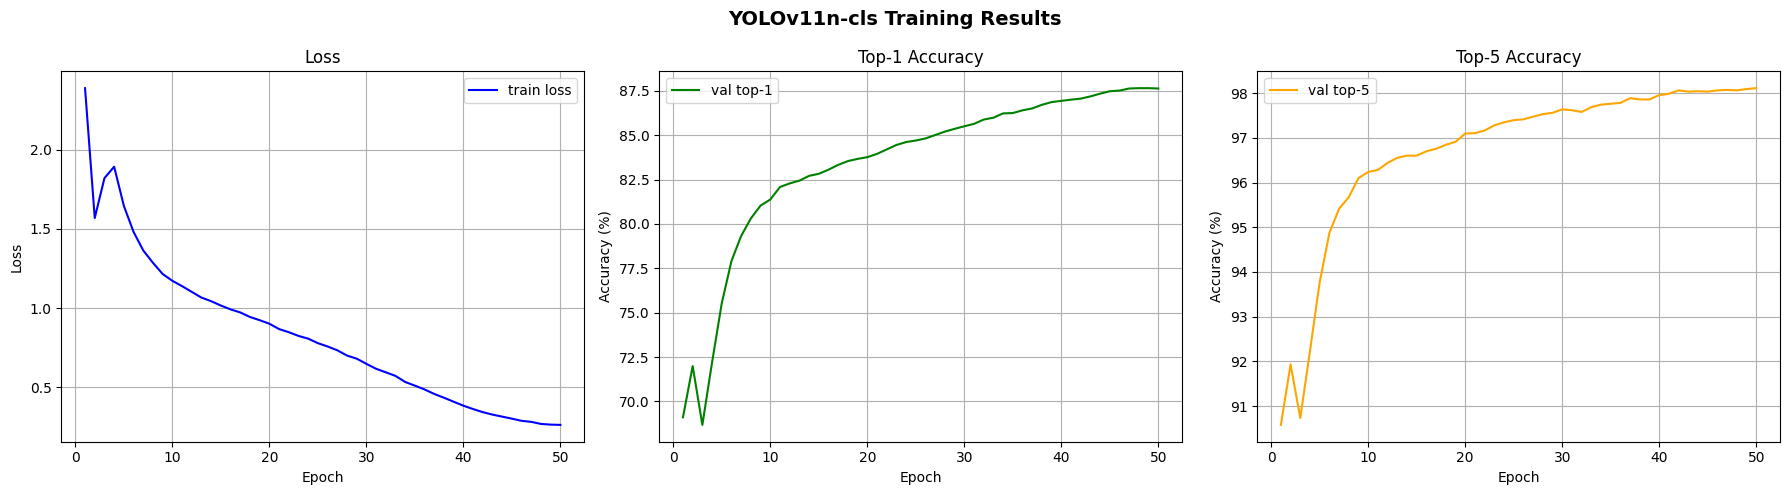

Best Top-1: 87.66%
Best Top-5: 98.11%
Total epochs: 50


In [ ]:
df = pd.read_csv('docs/yolo11_runs/yolo11_classifier_v1/results.csv')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('YOLOv11n-cls Training Results', fontsize=14, fontweight='bold')

# Loss plot
axes[0].plot(df['epoch'], df['train/loss'], label='train loss', color='blue')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Top-1 Accuracy
axes[1].plot(df['epoch'], df['metrics/accuracy_top1']*100, label='val top-1', color='green')
axes[1].set_title('Top-1 Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True)

# Top-5 Accuracy
axes[2].plot(df['epoch'], df['metrics/accuracy_top5']*100, label='val top-5', color='orange')
axes[2].set_title('Top-5 Accuracy')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Accuracy (%)')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.savefig('docs/yolo11_runs/yolo11_classifier_v1/training_curves.png', dpi=150)
plt.show()

print(f"Best Top-1: {df['metrics/accuracy_top1'].max()*100:.2f}%")
print(f"Best Top-5: {df['metrics/accuracy_top5'].max()*100:.2f}%")
print(f"Total epochs: {len(df)}")

Ultralytics 8.4.42 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
YOLO11n-cls summary (fused): 47 layers, 1,742,513 parameters, 0 gradients, 3.3 GFLOPs
train: /content/Mushrooms/data/dataset_split/train... found 83202 images in 169 classes ✅ 
val: /content/Mushrooms/data/dataset_split/val... found 10337 images in 169 classes ✅ 
test: /content/Mushrooms/data/dataset_split/test... found 10549 images in 169 classes ✅ 
test: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1512.4±432.4 MB/s, size: 45.6 KB)
test: Scanning /content/Mushrooms/data/dataset_split/test... 10549 images, 0 corrupt: 100% ━━━━━━━━━━━━ 10549/10549 4.0Git/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 660/660 55.7it/s 11.8s
                   all      0.877      0.981
Speed: 0.1ms preprocess, 0.6ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /content/Mushrooms/runs/classify/val-2
Available plots: ['confusion_matrix_normalized.png', 'results.png'

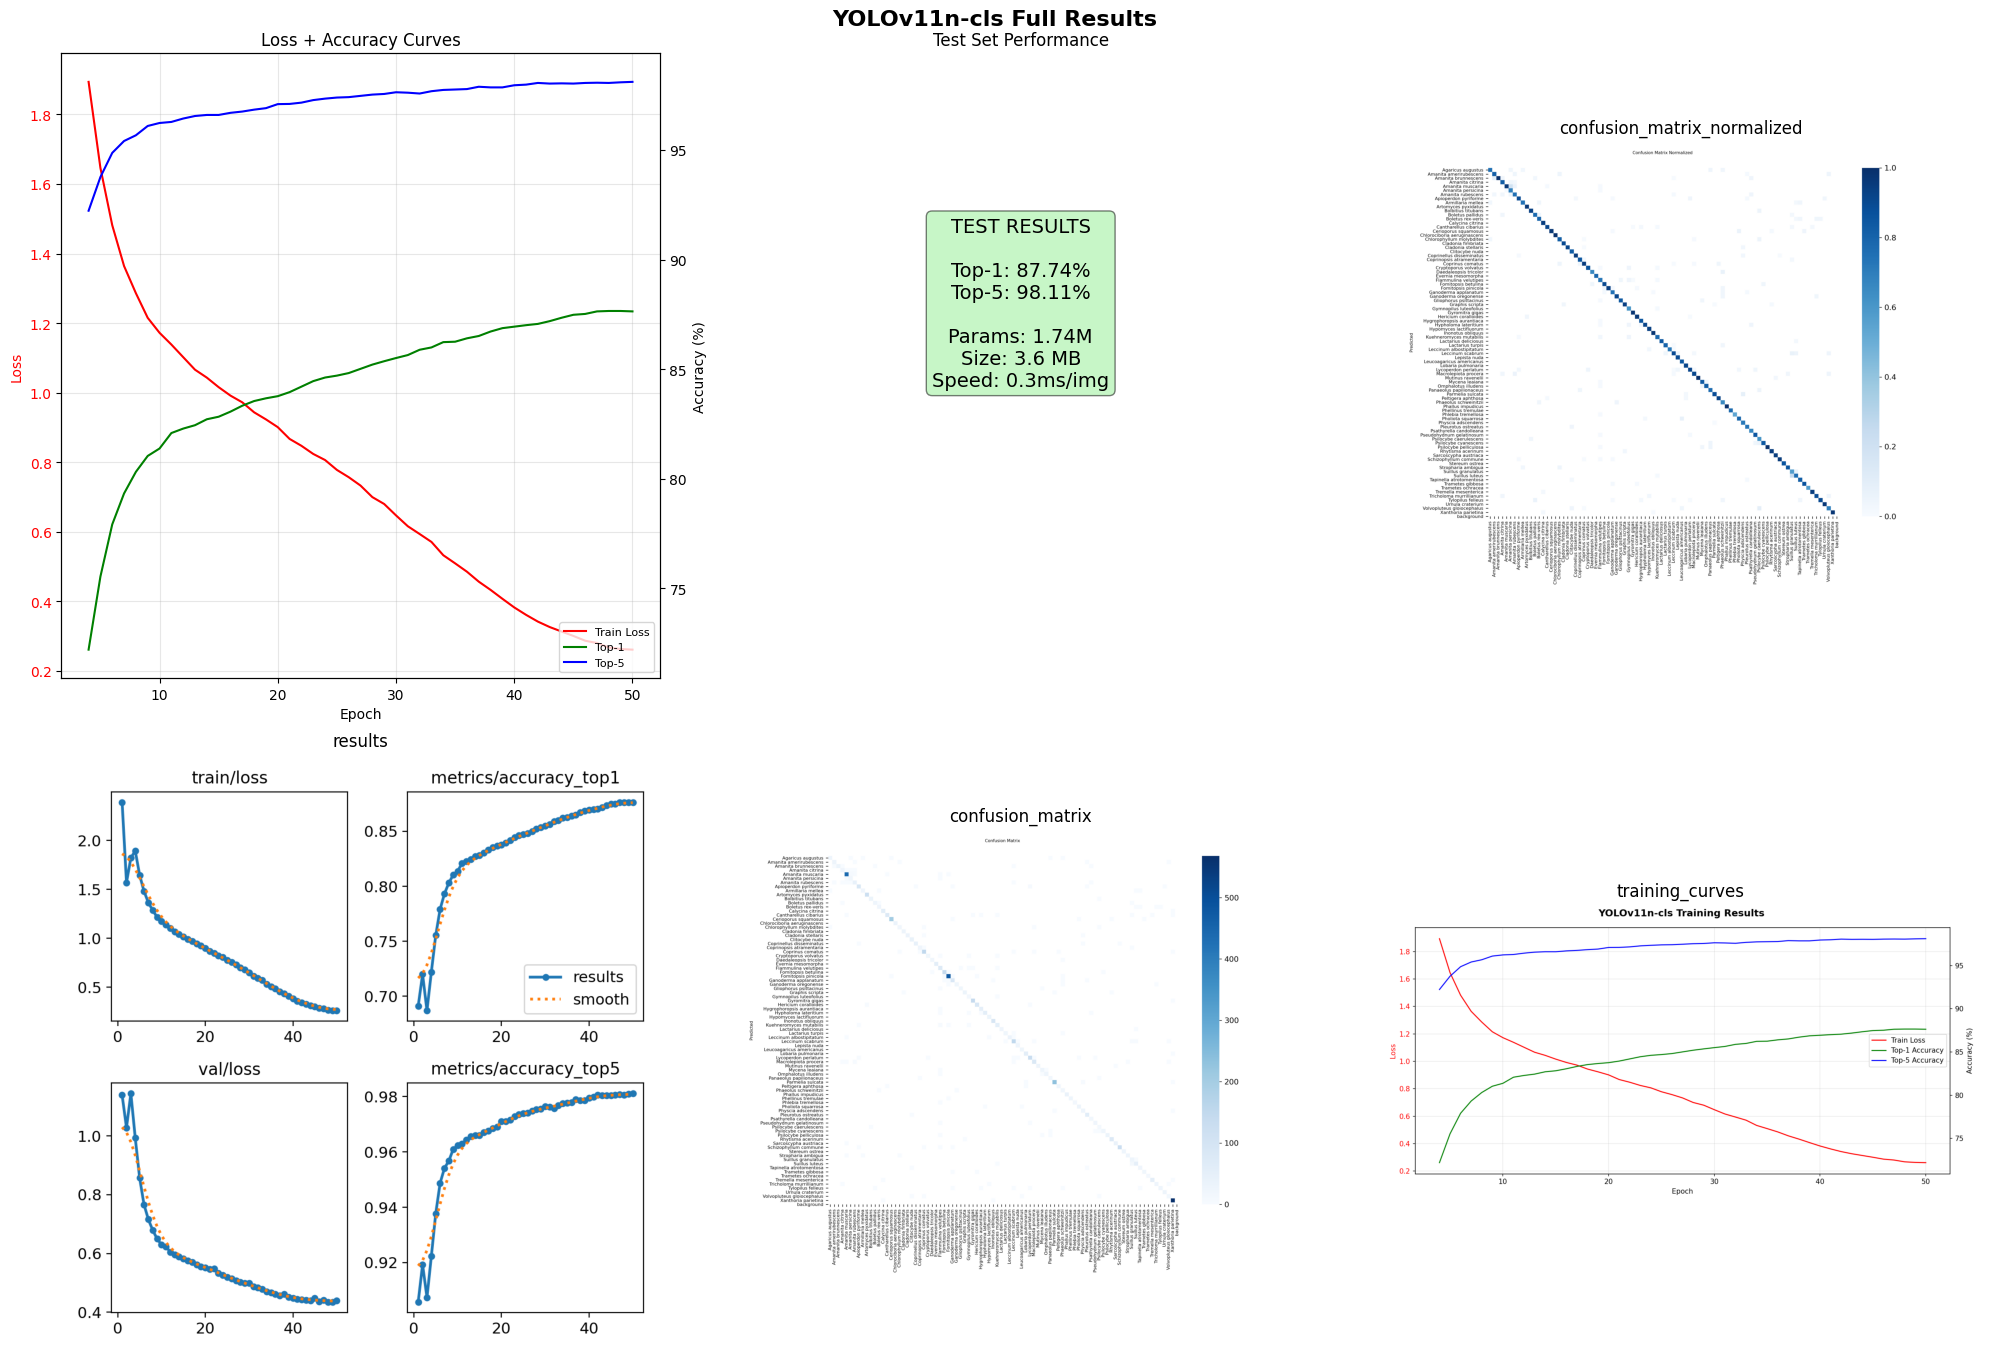


  YOLOv11 TEST RESULTS
  Top-1 Accuracy : 87.74%
  Top-5 Accuracy : 98.11%


In [ ]:
# ── 1. Test evaluation ────────────────────────────────────────
model = YOLO('docs/yolo11_runs/yolo11_classifier_v1/weights/best.pt')

results = model.val(
    data='data/dataset_split',
    split='test',
    imgsz=224,
)

top1 = results.results_dict['metrics/accuracy_top1'] * 100
top5 = results.results_dict['metrics/accuracy_top5'] * 100

# ── 2. Training curves ────────────────────────────────────────
df = pd.read_csv('docs/yolo11_runs/yolo11_classifier_v1/results.csv')
df = df[df['epoch'] > 3].reset_index(drop=True)

# ── 3. Find generated plots ───────────────────────────────────
run_dir = 'docs/yolo11_runs/yolo11_classifier_v1'
plot_files = [f for f in os.listdir(run_dir) if f.endswith('.png')]
print(f"Available plots: {plot_files}")

# ── 4. Big figure with everything ────────────────────────────
fig = plt.figure(figsize=(20, 14))
fig.suptitle('YOLOv11n-cls Full Results', fontsize=16, fontweight='bold')

# Row 1 — training curves
ax1 = fig.add_subplot(2, 3, 1)
ax2 = ax1.twinx()
ax1.plot(df['epoch'], df['train/loss'], color='red', label='Train Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss', color='red')
ax1.tick_params(axis='y', labelcolor='red')
ax2.plot(df['epoch'], df['metrics/accuracy_top1']*100, color='green', label='Top-1')
ax2.plot(df['epoch'], df['metrics/accuracy_top5']*100, color='blue', label='Top-5')
ax2.set_ylabel('Accuracy (%)')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right', fontsize=8)
ax1.set_title('Loss + Accuracy Curves')
ax1.grid(True, alpha=0.3)

# Row 1 — test results text box
ax_text = fig.add_subplot(2, 3, 2)
ax_text.axis('off')
ax_text.text(0.5, 0.6, f'TEST RESULTS\n\nTop-1: {top1:.2f}%\nTop-5: {top5:.2f}%\n\nParams: 1.74M\nSize: 3.6 MB\nSpeed: 0.3ms/img',
             transform=ax_text.transAxes,
             fontsize=14, verticalalignment='center', horizontalalignment='center',
             bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))
ax_text.set_title('Test Set Performance')

# Row 2 — show available PNG plots from training
for i, plot_file in enumerate(plot_files[:4]):
    ax = fig.add_subplot(2, 3, i + 3)
    img = mpimg.imread(os.path.join(run_dir, plot_file))
    ax.imshow(img)
    ax.set_title(plot_file.replace('.png', ''))
    ax.axis('off')

plt.tight_layout()
plt.savefig('docs/yolo11_runs/yolo11_classifier_v1/full_results.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n{'='*40}")
print(f"  YOLOv11 TEST RESULTS")
print(f"{'='*40}")
print(f"  Top-1 Accuracy : {top1:.2f}%")
print(f"  Top-5 Accuracy : {top5:.2f}%")
print(f"{'='*40}")

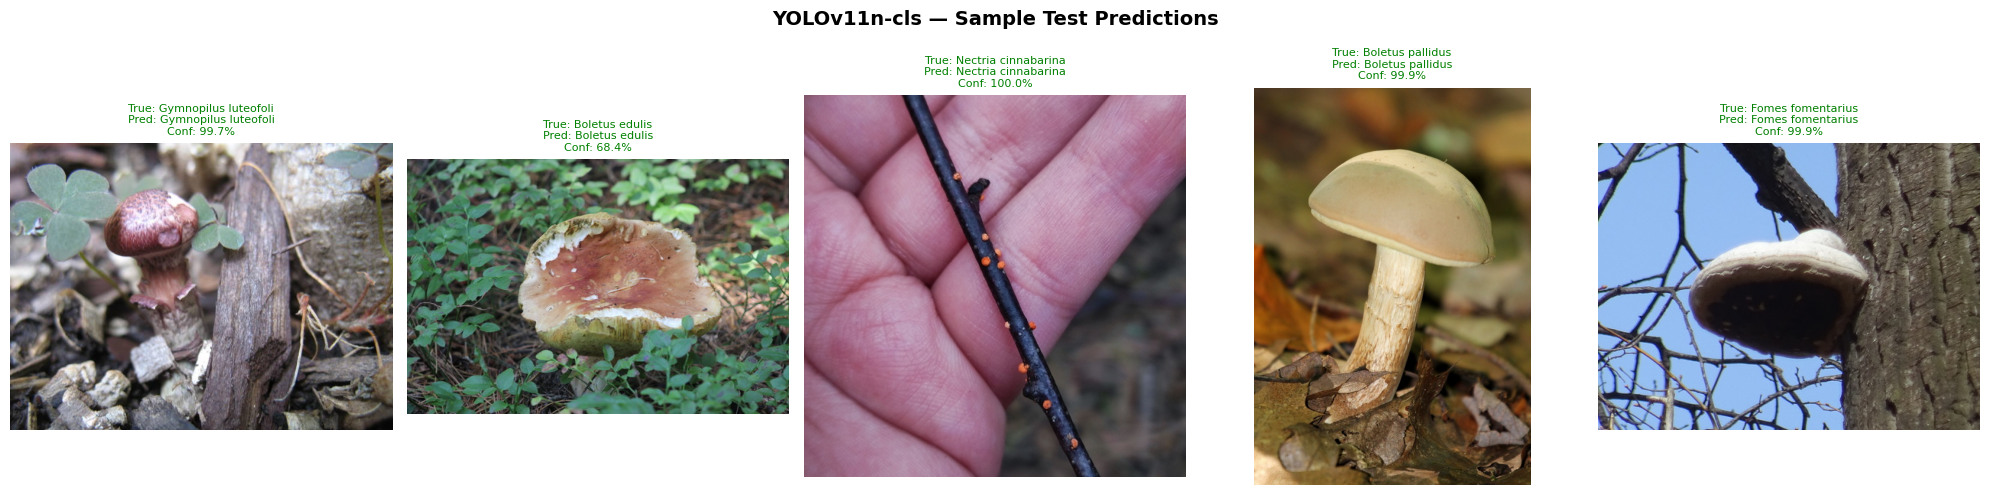

Correct: 5/5


In [ ]:
# ── Load model ────────────────────────────────────────────────
model = YOLO('docs/yolo11_runs/yolo11_classifier_v1/weights/best.pt')

# ── Get 5 random test images ──────────────────────────────────
test_dir = 'data/dataset_split/test'
all_images = []
for species in os.listdir(test_dir):
    species_path = os.path.join(test_dir, species)
    if os.path.isdir(species_path):
        for img_file in os.listdir(species_path):
            if img_file.endswith(('.jpg', '.jpeg', '.png')):
                all_images.append((os.path.join(species_path, img_file), species))

random.seed(42)
sample_images = random.sample(all_images, 5)

# ── Run predictions ───────────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
fig.suptitle('YOLOv11n-cls — Sample Test Predictions', fontsize=14, fontweight='bold')

for i, (img_path, true_label) in enumerate(sample_images):
    # Predict
    result = model.predict(img_path, verbose=False)[0]
    pred_label = result.names[result.probs.top1]
    confidence = result.probs.top1conf.item() * 100

    # Display
    img = mpimg.imread(img_path)
    axes[i].imshow(img)
    axes[i].axis('off')

    # Color green if correct, red if wrong
    color = 'green' if pred_label == true_label else 'red'

    axes[i].set_title(
        f'True: {true_label[:20]}\nPred: {pred_label[:20]}\nConf: {confidence:.1f}%',
        fontsize=8, color=color
    )

plt.tight_layout()
plt.savefig('docs/yolo11_runs/yolo11_classifier_v1/sample_predictions.png', dpi=150)
plt.show()

# ── Count correct ─────────────────────────────────────────────
correct = sum(1 for img_path, true_label in sample_images
              if model.predict(img_path, verbose=False)[0].names[
                  model.predict(img_path, verbose=False)[0].probs.top1] == true_label)
print(f"Correct: {correct}/5")



---


# **4. Export YOLO11n-cls to TFLite**

---



In [ ]:
  # Laod already trained model
model = YOLO("/content/Mushrooms/docs/yolo11_runs/yolo11_classifier_v1/weights/best.pt")

# Export to TFLite - takes 1-2 minutes
model.export(format='tflite', imgsz=224, half=True)
print("Done!")

Ultralytics 8.4.42 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.20GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLO11n-cls summary (fused): 47 layers, 1,742,513 parameters, 0 gradients, 3.3 GFLOPs

PyTorch: starting from '/content/Mushrooms/docs/yolo11_runs/yolo11_classifier_v1/weights/best.pt' with input shape (1, 3, 224, 224) BCHW and output shape(s) (1, 169) (3.5 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 388ms
Prepared 4 packages in 3.33s
Installed 4 packages in 303ms
 + colorama==0.4.6
 + onnx==1.21.0
 + onnxruntime-gpu==1.25.1
 + onnxslim==0.1.91

requirements: AutoUpdate success ✅ 4.6s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx

In [ ]:
# Download
from google.colab import files
files.download('/content/Mushrooms/docs/yolo11_runs/yolo11_classifier_v1/weights/best_saved_model/best_float16.tflite')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>